In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import geopandas as gpd
from shapely.geometry import Point
from collections import defaultdict

# Otu table

In [2]:
otus = {
    "coevolve":  pd.read_csv("../data/otu/otu_intersect_bp_coevolve.csv").set_index("match_name"),
    "tara":      pd.read_csv("../data/otu/otu_intersect_bp_tara.csv").set_index("match_name"),
    "neon":      pd.read_csv("../data/otu/otu_intersect_bp_neon.csv").set_index("match_name"),
    "ncbi":      pd.read_csv("../data/otu/otu_intersect_bp_ncbi.csv").set_index("match_name"),
    "malaspina": pd.read_csv("../data/otu/otu_intersect_bp_malaspina.csv").set_index("match_name"),
    "ena":       pd.read_csv("../data/otu/otu_intersect_bp_ena.csv").set_index("match_name"),
}

for name, otu in otus.items():
    print(f"{name}: {otu.shape[0]} rows, {otu.shape[1]} samples")



coevolve: 12911 rows, 421 samples
tara: 11409 rows, 246 samples
neon: 12532 rows, 1183 samples
ncbi: 10878 rows, 110 samples
malaspina: 9276 rows, 58 samples
ena: 11407 rows, 44 samples


Remove wrong samples 

In [3]:
prefixes_to_remove = ( #removed samples because we currently do not have usage rights, or because they are ambiguous (background soil/water with possible subsurface influence)+ seawater samples from CN5
    "PG_172224", "PL_170224", 
    "AR_170220_3",  "S14", 
    "DAI_230627", "KON_230628_", "OYU2_230629_F", 
    "VL1_240623", "VL2_240623", "VL3_240623", "VL4_240623", "VL5_240623", "VP6_240624", 
    "T1", "T2", "T3", "T4", "T5", "T6", "T7", "T8", "T9", 
    "GRP_230724_S", 
    "DS_F", 
)

for name in list(otus):
    cols = [c for c in otus[name].columns if c.startswith(prefixes_to_remove)]
    otus[name].drop(columns=cols, inplace=True)

print("Initial number of metaG (after bad sample removal):")
for name, otu in otus.items():
    print(f"  {name}: {otu.shape[1]} metagenomes")


# Count the number of unique sites explored in CoEvolve
sites = [s.split("_")[0] for s in otus["coevolve"].columns]
sites_clean = [re.sub(r"\d+$", "", site) for site in sites]#some sites are sampled at different points and have a number in their name to indicate that (ex: BR1, BR2) -> remove the number to count only once
sites_clean = [s for s in sites_clean if s not in {"SF1D", "SF2A", "SF2B", "SF2C"}] # remove SF1D, SF2A, SF2B, SF2C since they are all similar site than SF (Secca delle Fumose)
sites_clean = [s for s in sites_clean if s not in {"VC"}] # remove VC since VC_190908_S is a soil (note that TM_190224_UN and PB_170224 are also soils but we have samples TM and PB that are true subsurface samples so we dont remove them from the list in order to count them
print(f"\nList of sites: {', '.join(sorted(set(sites_clean)))}")
print(f"Number of unique sites sampled in CoEvolve: {len(set(sites_clean))}")


Initial number of metaG (after bad sample removal):
  coevolve: 376 metagenomes
  tara: 246 metagenomes
  neon: 1183 metagenomes
  ncbi: 110 metagenomes
  malaspina: 58 metagenomes
  ena: 44 metagenomes

List of sites: AC, AG, AO, AU, AV, BA, BC, BF, BJ, BM, BO, BP, BQ, BR, BRH, BS, BST, BW, CA, CB, CBP, CC, CE, CF, CG, CGV, CH, CI, CL, CM, CN, CP, CQ, CR, CT, CU, CV, CW, CY, CZ, EM, EP, EQ, ER, ES, ET, FA, FC, FE, FR, FRH, FV, FYW, GA, GB, GE, GF, GI, GLR, GN, GS, GU, GV, HA, HC, HO, HTV, HV, IN, IS, JB, JJH, JR, KJ, KR, KT-, KU, LA, LB, LC, LE, LF, LH, LMR, LN, LP, LR, LS, LV, LW, MC, ML, MSS, MT, MTZ, MV, NF-, NJ, NR, OA, OR, OS, OY, OZ, P3V, PB, PDL, PDS, PF, PG, PI, PJ, PJS, PM, PO, PP, PQ, PR, PS, PX, QG, QH, QN, QW, RC, RCA, RCB, RCD, RCE, RCF, RF, RF-, RMV, RR, RS, RSW, RV, SA, SB, SC, SDL, SDS, SF, SG, SI, SJ, SL, SM, SN, SP, SR, TA, TAW, TC, TCP, TF, TL, TM, TP, TQ, TR, TT, TZ, UH, UK, UN, VA, VB, VL, VMB, VR, VSS, VTS, VV, XF, YR
Number of unique sites sampled in CoEvolve: 1

rpoB quantile filtering

In [4]:
def get_rpoB_total(df):
    df = df.apply(pd.to_numeric)
    total = df.loc[["K03043", "K13797"]].sum(axis=0, skipna=True) \
            + df.loc[["K03044", "K03045"]].mean(axis=0, skipna=True) \
            + df.loc["K13798"]
    return total

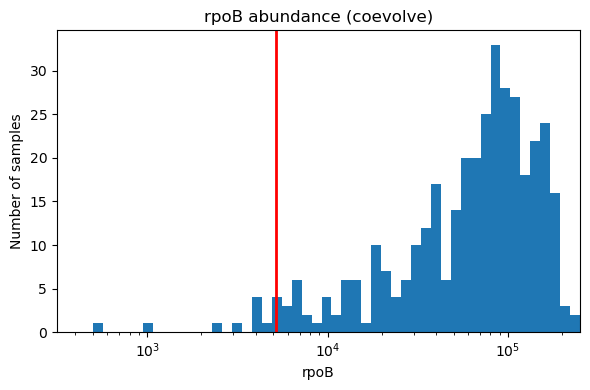

coevolve: dropped 19 of 376 samples
  Dropped: ['VL_220828_F', 'AG17_S', 'AG27_S', 'GF2_190226_S', 'LC_190226_S', 'RF_190301_S', 'TM_190224_F', 'BQ_170218_F', 'BQ_170218_S2', 'AC_190614_F', 'BR1_190716_F', 'BR2_190717_F', 'EP_190616_F', 'LP_190617_F', 'LW_190703_F', 'SA_190716_F', 'SC_190909_S', 'GN1_210601_S', 'GN2_210601_S']


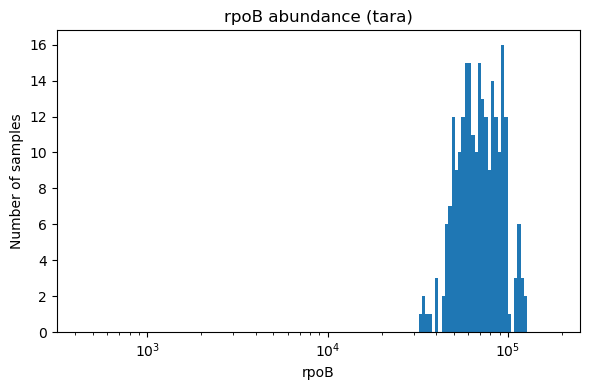

tara: no filtering applied, metagenomes already cleaned


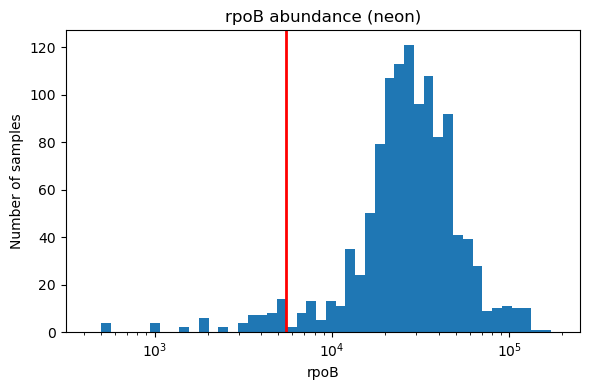

neon: dropped 58 of 1183 samples
  Dropped: ['ARIK.20210707.EPIPSAMMON.3', 'BIGC.20180724.AMC.EPIPSAMMON.1', 'BIGC.20180724.AMC.EPIPSAMMON.3', 'BIGC.20180724.AMC.EPIPSAMMON.4', 'BLUE.20180712.AMC.EPILITHON.4', 'CARI.SS.20200804', 'CLBJ_001-M-20190416-COMP', 'CLBJ_006-M-20190416-COMP', 'CPER_002-M-20210628-COMP', 'CPER_048-M-20210628-COMP', 'CRAM.C1.20200804', 'DSNY_005-M-20180820-COMP', 'GUAN_004-M-20180925-COMP', 'HARV_001-M-20180710-COMP', 'HARV_021-M-20180712-COMP', 'HARV_037-O-20180710-COMP', 'HEAL_001-O-20210623-COMP', 'HEAL_005-O-20210623-COMP', 'KING.20200728.EPILITHON.7', 'KING.SS.20200803', 'KONA_001-M-20190619-COMP', 'KONA_006-M-20190617-COMP', 'KONA_057-M-20190618-COMP', 'LAJA_002-M-20201021-COMP', 'LECO.20180724.AMC.EPILITHON.2', 'LEWI.20180710.AMC.EPILITHON.1', 'LEWI.20180710.AMC.EPIPELON.1', 'LEWI.SS.20200729', 'LIRO.C1.20200803', 'MART.20200716.EPILITHON.1', 'MART.20200716.EPILITHON.2', 'MART.20200716.EPILITHON.3', 'MART.20200716.EPILITHON.5', 'MART.20200716.EPILITHON.6'

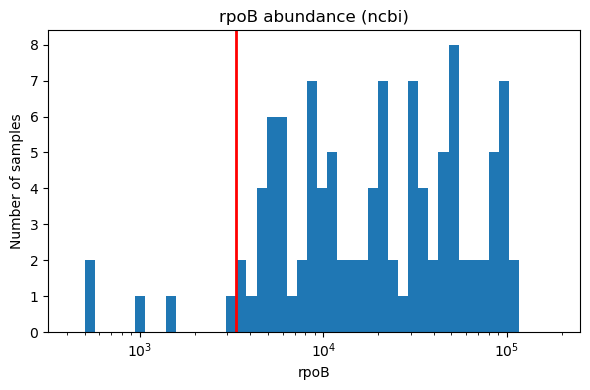

ncbi: dropped 6 of 110 samples
  Dropped: ['SRR5273290', 'SRR5468442', 'SRR5468443', 'SRR5650782', 'SRR6244844', 'SRR6244845']


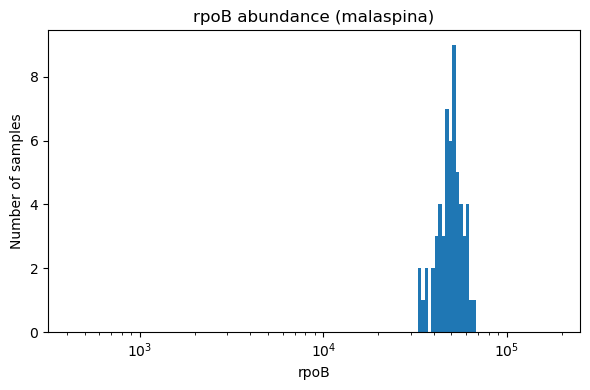

malaspina: no filtering applied, metagenomes already cleaned


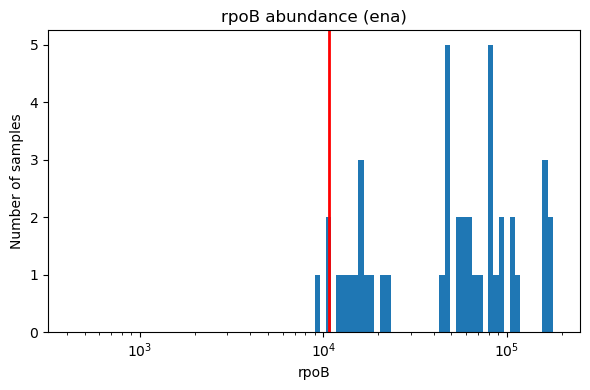

ena: dropped 3 of 44 samples
  Dropped: ['ERR1877651', 'ERR1877728', 'ERR1877814']


In [5]:
quantile_cutoff = 0.05

# True = apply rpoB quantile filter; False = dataset already pre-cleaned (Tara and malapsina are already clean)
apply_filter = {
    "coevolve": True,
    "neon":     True,
    "ncbi":     True,
    "tara":     False,
    "malaspina":False,
    "ena":      True,
}

for name, otu in otus.items():
    rpob = get_rpoB_total(otu)
    rpob = rpob[otu.columns]

    cutoff = np.quantile(rpob, quantile_cutoff)

    min_val = max(rpob[rpob > 0].min(), 10**2.5)
    max_val = 10**5.4
    bins = np.logspace(np.log10(min_val), np.log10(max_val), 50)

    plt.figure(figsize=(6, 4))
    plt.hist(rpob[rpob > 0], bins=bins)
    if apply_filter[name]:
        plt.axvline(cutoff, color="red", linewidth=2)
    plt.title(f"rpoB abundance ({name})")
    plt.xlabel("rpoB")
    plt.ylabel("Number of samples")
    plt.xscale("log")
    plt.xlim(10**2.5, 10**5.4)
    plt.tight_layout()
    plt.show()

    if apply_filter[name]:
        keep = rpob >= cutoff
        dropped = rpob.index[~keep].tolist()
        otus[name] = otu.loc[:, keep]
        print(f"{name}: dropped {(~keep).sum()} of {len(keep)} samples")
        if dropped:
            print(f"  Dropped: {dropped}")
    else:
        print(f"{name}: no filtering applied, metagenomes already cleaned")


Low annotated metaG filtering

In [6]:
for name, otu in otus.items():
    low_annotations = [
        col for col in otu.columns
        if (otu[col] > 0).mean(skipna=True) < 0.20
    ]
    print(f"\nSamples with < 20% annotated functions in {name}:")
    print(pd.DataFrame({
        "Column_Number": [otu.columns.get_loc(col) + 1 for col in low_annotations],
        "Column_Name": low_annotations
    }))
    otus[name] = otu.drop(columns=low_annotations, errors="ignore")
    print(otus[name].shape)



Samples with < 20% annotated functions in coevolve:
    Column_Number   Column_Name
0              18  GF1_190226_F
1              19  GF1_190226_S
2              20  GF2_190226_F
3              21   IN_190223_F
4              23   LC_190226_F
5              48   CP_200307_F
6              49   CQ_200302_F
7              56   PM_200308_S
8              60   TF_200303_S
9             169   BQ_190717_F
10            176   HC_220127_F
11            181  RCE_190801_F
12            182  RCF_190801_F
13            186   SL_190717_S
14            187   VB_190611_F
15            192   CG_211015_F
16            193   CG_211015_S
17            208   SP_210924_F
18            256   LN_230313_S
19            310  GN2_210601_F
20            311  HV1_210602_F
21            312  HV1_210602_S
22            317  KR2_210530_F
23            318  KR2_210530_S
(12911, 333)

Samples with < 20% annotated functions in tara:
Empty DataFrame
Columns: [Column_Number, Column_Name]
Index: []
(11409, 246)

Samples

rpoB normalization

In [7]:
otu_rpos = {}

for name, otu in otus.items():
    otu = otu.apply(pd.to_numeric)
    otu_rpo = otu.div(get_rpoB_total(otu), axis=1)
    otu_rpos[name] = otu_rpo

    print(f"{name}: rpo={otu_rpo.shape}")


coevolve: rpo=(12911, 333)
tara: rpo=(11409, 246)
neon: rpo=(12532, 1081)
ncbi: rpo=(10878, 82)
malaspina: rpo=(9276, 58)
ena: rpo=(11407, 41)


# Tax table

In [8]:
tax = pd.read_csv("../data/tax/ko_carbon_metab.csv", header=0, sep=",")

tax['trophic_mode'] = tax['pathway'].apply(
    lambda x: 'hetero' if x == 'other' else ('auto' if 'other' not in x else 'auto|hetero')
)

existing_kos = tax['ko'].values

all_kos = pd.Index(set().union(*[df.index for df in otus.values()]))
missing_kos = [ko for ko in all_kos if ko not in existing_kos]

new_rows = pd.DataFrame(
    data=np.nan,
    index=range(len(missing_kos)),
    columns=tax.columns
)
new_rows['ko'] = missing_kos

tax = pd.concat([tax, new_rows], ignore_index=True)


mask = tax["key_genes"].str.contains("_1", na=False)
tax.loc[mask, "pathway"] = tax.loc[mask, "pathway"] + "|cfp"

tax.set_index("ko", inplace=True)

Add Kegg functions

In [9]:
excluded_categories = {
    "Brite Hierarchies",
    "Human Diseases",
    "Not Included in Pathway or Brite",
}

ko_to_functions = defaultdict(set)
ko_to_metabolism_sub = defaultdict(set)
ko_to_energy_sub = defaultdict(set)

current_A_label = None
current_B_label = None
current_C_label = None

with open("../data/reference/ko00001.keg", "r") as f:
    for line in f:
        line = line.rstrip()

        if line.startswith("A"):
            parts = line[1:].strip().split(" ", 1)
            current_A_label = parts[1] if len(parts) == 2 else None
            current_B_label = None
            current_C_label = None

        elif line.startswith("B") and current_A_label is not None:
            parts = line[1:].strip().split(" ", 1)
            current_B_label = parts[1] if len(parts) == 2 else None
            current_C_label = None

        elif line.startswith("C") and current_A_label == "Metabolism" and current_B_label == "Energy metabolism":
            parts = line[1:].strip().split(" ", 1)
            current_C_label = parts[1] if len(parts) == 2 else None

        elif line.startswith("D") and current_A_label is not None:
            ko = line.split()[1]

            if current_A_label not in excluded_categories:
                ko_to_functions[ko].add(current_A_label)

            if current_A_label == "Metabolism" and current_B_label is not None:
                ko_to_metabolism_sub[ko].add(current_B_label)

            if current_A_label == "Metabolism" and current_B_label == "Energy metabolism" and current_C_label is not None:
                ko_to_energy_sub[ko].add(current_C_label)

tax["global_function"] = tax.index.map(
    lambda x: ";".join(sorted(ko_to_functions[x])) if x in ko_to_functions else "Other"
)

tax["metabolism_sub_function"] = tax.index.map(
    lambda x: ";".join(sorted(ko_to_metabolism_sub[x])) if x in ko_to_metabolism_sub else "Other"
)

tax["energy_metabolism_sub_function"] = tax.index.map(
    lambda x: ";".join(sorted(ko_to_energy_sub[x])) if x in ko_to_energy_sub else "Other"
)

tax["energy_metabolism_sub_function"] = tax["energy_metabolism_sub_function"].map(
    lambda entry: entry if entry == "Other" else ";".join(re.sub(r" \[PATH:.*?\]", "", p) for p in entry.split(";"))
)

tax["energy_metabolism_sub_function"] = tax["energy_metabolism_sub_function"].map(
    lambda entry: entry if entry == "Other" else ";".join(sorted(
        "Carbon fixation" if ("Carbon fixation by Calvin cycle" in p or "Other carbon fixation pathways" in p) else p
        for p in set(entry.split(";"))
    ))
)

tax

,gene_name,gene_description,ec_1,ec_2,ec_3,ec_4,glycolysis,gluconeogenesis,ppp,prpp_biosynthesis,...,sped_2,methylaspartate_cycle,propanoylCoA_metabolism,methylcitrate_cycle,pathway,key_genes,trophic_mode,global_function,metabolism_sub_function,energy_metabolism_sub_function
ko,,,,,,,,,,,,,,,,,,,,,
K00018,hprA,glycerate dehydrogenase,1.1.1.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,other,NaN,hetero,Metabolism,Amino acid metabolism;Carbohydrate metabolism;...,Methane metabolism
K00023,phbB,acetoacetyl-CoA reductase,1.1.1.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,other,NaN,hetero,Metabolism,Carbohydrate metabolism,Other
K00024,mdh,malate dehydrogenase,1.1.1.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,1.0,dchb|rtca|other,NaN,auto|hetero,Metabolism,Amino acid metabolism;Carbohydrate metabolism;...,Carbon fixation;Carbon fixation;Methane metabo...
K00025,MDH1,malate dehydrogenase,1.1.1.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,other,NaN,hetero,Metabolism;Organismal Systems,Amino acid metabolism;Carbohydrate metabolism;...,Carbon fixation
K00026,MDH2,malate dehydrogenase,1.1.1.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,other,NaN,hetero,Metabolism,Amino acid metabolism;Carbohydrate metabolism;...,Carbon fixation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
K00819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Metabolism,Amino acid metabolism,Other
K02057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,Other,Other
K20379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cellular Processes,Other,Other


Add missing gene_name and gene_description

In [10]:
ko_to_name = {}
ko_to_description = {}

with open("../data/reference/ko00001.keg", "r") as f:
    for line in f:
        line = line.rstrip()
        if line.startswith("D"):
            parts = line.split(None, 2)
            if len(parts) < 3:
                continue
            ko = parts[1]
            rest = parts[2]

            rest_clean = re.sub(r" \[PATH:.*?\]", "", rest)
            split_rest = rest_clean.split(" ", 1)
            gene_name = split_rest[0].rstrip(";,")
            gene_description = split_rest[1] if len(split_rest) > 1 else ""
            gene_description = re.sub(r" \[EC:.*?\]$", "", gene_description)

            ko_to_name[ko] = gene_name
            ko_to_description[ko] = gene_description

tax["gene_name"] = tax.apply(
    lambda row: ko_to_name.get(row.name, row["gene_name"]) if pd.isna(row["gene_name"]) or row["gene_name"] == "" else row["gene_name"],
    axis=1
)

tax["gene_description"] = tax.apply(
    lambda row: ko_to_description.get(row.name, row["gene_description"]) if pd.isna(row["gene_description"]) or row["gene_description"] == "" else row["gene_description"],
    axis=1
)

tax

,gene_name,gene_description,ec_1,ec_2,ec_3,ec_4,glycolysis,gluconeogenesis,ppp,prpp_biosynthesis,...,sped_2,methylaspartate_cycle,propanoylCoA_metabolism,methylcitrate_cycle,pathway,key_genes,trophic_mode,global_function,metabolism_sub_function,energy_metabolism_sub_function
ko,,,,,,,,,,,,,,,,,,,,,
K00018,hprA,glycerate dehydrogenase,1.1.1.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,other,NaN,hetero,Metabolism,Amino acid metabolism;Carbohydrate metabolism;...,Methane metabolism
K00023,phbB,acetoacetyl-CoA reductase,1.1.1.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,other,NaN,hetero,Metabolism,Carbohydrate metabolism,Other
K00024,mdh,malate dehydrogenase,1.1.1.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,1.0,dchb|rtca|other,NaN,auto|hetero,Metabolism,Amino acid metabolism;Carbohydrate metabolism;...,Carbon fixation;Carbon fixation;Methane metabo...
K00025,MDH1,malate dehydrogenase,1.1.1.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,other,NaN,hetero,Metabolism;Organismal Systems,Amino acid metabolism;Carbohydrate metabolism;...,Carbon fixation
K00026,MDH2,malate dehydrogenase,1.1.1.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,other,NaN,hetero,Metabolism,Amino acid metabolism;Carbohydrate metabolism;...,Carbon fixation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
K00819,rocD,OAT; ornithine--oxo-acid transaminase,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Metabolism,Amino acid metabolism,Other
K02057,ABC.SS.P,simple sugar transport system permease protein,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,Other,Other
K20379,cad,sex pheromone cAD1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cellular Processes,Other,Other


# Env table

In [11]:
env_coevolve_ncbi = pd.read_csv("../data/env/env.csv", header=0, sep=",", index_col="run")
env_coevolve_ncbi = env_coevolve_ncbi.drop(
    index=[idx for idx in env_coevolve_ncbi.index if idx.startswith(prefixes_to_remove)],
    errors="ignore"
)

# Published vs unpublished split for the coevolve dataset
print(f"coevolve: {len(otus['coevolve'].columns)} metagenomes")
print(f"  published (has DOI): {env_coevolve_ncbi.reindex(otus['coevolve'].columns)['doi'].notna().sum()}")
print(f"  unpublished:         {env_coevolve_ncbi.reindex(otus['coevolve'].columns)['doi'].isna().sum()}")

env_malaspina = pd.read_csv("../data/env/env_malaspina.csv", header=0, sep=",", index_col="run")
env_malaspina = env_malaspina[env_malaspina["size fraction"] == "[0.2-0.8µm]"]

env_tara = pd.read_csv("../data/env/env_tara.csv", header=0, sep=",", index_col="selected_run")

env_neon = pd.read_csv("../data/env/env_neon.csv", header=0, sep=",", index_col="sampleID")

env_ena = pd.read_csv("../data/env/env_ena.csv", sep=",", index_col="run")

env = pd.concat([env_coevolve_ncbi, env_tara, env_neon, env_malaspina, env_ena], axis=0)
env

coevolve: 333 metagenomes
  published (has DOI): 88
  unpublished:         245


/var/folders/xd/tzd66fkj5s5676432q_qccqr0000gn/T/ipykernel_77246/217294094.py:17: DtypeWarning: Columns (10,12,13,16,67,68,69,71) have mixed types. Specify dtype option on import or set low_memory=False.
  env_neon = pd.read_csv("../data/env/env_neon.csv", header=0, sep=",", index_col="sampleID")


,CollectionID,ExpID,SiteID,site_name,series,continent,country,year,date,tectonicType1,...,OGA_ID,size fraction,filter_size (µm),Ocean,DIC,depth_m,scientific_name,env_biome,env_feature,env_material
PB_190912_S,PB_190912,AEO19,PB,Pietra del Bagno,8,EUR,ITA,2019.0,2019-09-12,plate margin,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PB_190912_F,PB_190912,AEO19,PB,Pietra del Bagno,8,EUR,ITA,2019.0,2019-09-12,plate margin,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BO_190909_B,BO_190909,AEO19,BO,Bottaro,6,EUR,ITA,2019.0,2019-09-09,plate margin,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BO_190909_S,BO_190909,AEO19,BO,Bottaro,6,EUR,ITA,2019.0,2019-09-09,plate margin,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PO_190911_F,PO_190911,AEO19,PO,Pollara,7,EUR,ITA,2019.0,2019-09-11,plate margin,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR24908192,NaN,public_archives,NaN,NaN,NaN,NaN,China: Tibet,NaN,2018,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,lake water metagenome,NaN,NaN,NaN
SRR24908171,NaN,public_archives,NaN,NaN,NaN,NaN,China: Tibet,NaN,2019,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,lake water metagenome,NaN,NaN,NaN
SRR24908198,NaN,public_archives,NaN,NaN,NaN,NaN,China: Tibet,NaN,2018,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,lake water metagenome,NaN,NaN,NaN
SRR30184006,NaN,public_archives,NaN,NaN,NaN,NaN,"Kenya: Kiambu,Gatundu-South",NaN,2022-10-17,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,soil metagenome,NaN,NaN,NaN


Check common columns

In [12]:
dfs = [env_coevolve_ncbi, env_tara, env_neon, env_malaspina, env_ena]
for i, df1 in enumerate(dfs):
    for j, df2 in enumerate(dfs):
        if i < j:
            common = df1.columns.intersection(df2.columns)
            if len(common) > 0:
                print(f"Common columns between df{i} and df{j}: {common.tolist()}")


Common columns between df0 and df1: ['ExpID', 'latitude', 'longitude', 'elevation', 'temp', 'ph', 'spc', 'tds', 'sal', 'alk_tot', 'no3', 'po4', 'co2_dis', 'o2_dis', 'project', 'doi', 'source', 'sample_accession', 'dic', 'sample_subgroup', 'sample_group', 'surface_subsurface']
Common columns between df0 and df2: ['ExpID', 'latitude', 'longitude', 'elevation', 'temp', 'ph', 'spc', 'do_sat', 'do', 'tds', 'cl', 'br', 'no3', 'so4', 'po4', 'na', 'nh4', 'k', 'mg', 'ca', 'mn', 'fe', 'project', 'doi', 'source', 'dic', 'sample_subgroup', 'sample_group', 'surface_subsurface']
Common columns between df0 and df3: ['ExpID', 'date', 'latitude', 'longitude', 'elevation', 'temp', 'tds', 'sal', 'o2_dis', 'project', 'doi', 'source', 'sample_accession', 'sample_subgroup', 'sample_group', 'surface_subsurface']
Common columns between df0 and df4: ['ExpID', 'country', 'date', 'latitude', 'longitude', 'elevation', 'temp', 'ph', 'spc', 'orp', 'do_sat', 'sal', 'alk_tot', 'sio2', 'sulfide', 'fe2', 'cl', 'br', 'n

Check duplicates

In [13]:
for df_name, df in [("env_coevolve_ncbi", env_coevolve_ncbi), ("env_malaspina", env_malaspina), ("env_tara", env_tara),
                    ("env_neon", env_neon),
                    ("env_ena", env_ena)]:
    duplicates = df.index[df.index.duplicated()]
    print(df_name, "duplicates:", duplicates)


env_coevolve_ncbi duplicates: Index([], dtype='object', name='run')
env_malaspina duplicates: Index([], dtype='object', name='run')
env_tara duplicates: Index([], dtype='object', name='selected_run')
env_neon duplicates: Index([], dtype='object', name='sampleID')
env_ena duplicates: Index([], dtype='object', name='run')


Remove replicate TARA runs

In [14]:
# in TARA, some metagenomes are replicate runs of the same sample. The representative is defined by the index of env_tara. Any column not in env_tara.index is a replicate —> drop

drop_cols = []
for mg in otu_rpos["tara"].columns:
    if mg not in env_tara.index:
        row = env_tara[env_tara["INSDC_ID"].str.contains(mg, regex=False)]
        if row.empty:
            raise ValueError(f"{mg} not found in env_tara")
        rep = row.index[0]
        if rep not in otu_rpos["tara"].columns:
            raise ValueError(f"{mg} removed but {rep} not present in rpo")
        print(f"{mg} not selected, represented by {rep}")
        drop_cols.append(mg)

for tbl in [otu_rpos, otus]:
    tbl["tara"] = tbl["tara"].drop(columns=drop_cols)

print("tara rpo after:", otu_rpos["tara"].shape[1], "samples")


ERR315860 not selected, represented by ERR315859
ERR315861 not selected, represented by ERR315858
ERR315863 not selected, represented by ERR315862
ERR318618 not selected, represented by ERR318620
ERR318619 not selected, represented by ERR318620
ERR318621 not selected, represented by ERR318620
ERR598943 not selected, represented by ERR598978
ERR598945 not selected, represented by ERR599059
ERR598946 not selected, represented by ERR598953
ERR598949 not selected, represented by ERR599082
ERR598950 not selected, represented by ERR599095
ERR598951 not selected, represented by ERR599043
ERR598952 not selected, represented by ERR599065
ERR598959 not selected, represented by ERR598991
ERR598962 not selected, represented by ERR599007
ERR598966 not selected, represented by ERR599143
ERR598969 not selected, represented by ERR599106
ERR598970 not selected, represented by ERR599150
ERR598972 not selected, represented by ERR599023
ERR598973 not selected, represented by ERR599173
ERR598974 not select

In [15]:
envs = {
    "coevolve":  env_coevolve_ncbi,
    "tara":      env_tara,
    "neon":      env_neon,
    "ncbi":      env_coevolve_ncbi,
    "malaspina": env_malaspina,
    "ena":       env_ena,
}

for name in list(otu_rpos):
    rpo     = otu_rpos[name]
    env_tbl = envs[name]

    missing_in_otu = [idx for idx in env_tbl.index if idx not in rpo.columns]
    print(f"{name}: env rows not in otu_rpo:", missing_in_otu)
    env_tbl = env_tbl.drop(index=missing_in_otu, errors="ignore")

    missing_in_env = [col for col in rpo.columns if col not in env_tbl.index]
    print(f"{name}: otu_rpo cols not in env (dropped):", missing_in_env)
    otu_rpos[name]      = rpo.drop(columns=missing_in_env, errors="ignore")
    envs[name]          = env_tbl

    print(f"{name}: {otu_rpos[name].shape[1]} samples after alignment")

otu_rpo = pd.concat(list(otu_rpos.values()), axis=1)
otu_rpo = otu_rpo.apply(lambda c: c.fillna(c.min()))

otu_all = pd.concat(list(otus.values()), axis=1)
otu_all = otu_all.apply(lambda c: c.fillna(c.min()))

env = pd.concat([env_coevolve_ncbi, env_tara, env_neon, env_malaspina, env_ena], axis=0)

shared = otu_rpo.columns.intersection(env.index)
otu_rpo      = otu_rpo.loc[:, shared]
otu_all      = otu_all.loc[:, shared]
env          = env.loc[shared]

print(f"otu_rpo:     {otu_rpo.shape}")
print(f"otu_all:     {otu_all.shape}")
print(f"env:         {env.shape}")


coevolve: env rows not in otu_rpo: ['TM_190224_F', 'IN_190223_F', 'LN_230313_S', 'PM_200308_S', 'TF_200303_S', 'BQ_170218_F', 'BQ_170218_S2', 'BR2_190717_F', 'BR1_190716_F', 'AC_190614_F', 'EP_190616_F', 'SP_210924_F', 'GN1_210601_S', 'DRR093002', 'DRR093003', 'DRR093004', 'DRR093005', 'DRR163686', 'DRR163690', 'DRR163693', 'SRR1556897', 'SRR1297186', 'SRR1297204', 'SRR2239652', 'SRR4453772', 'SRR3439968', 'SRR3440026', 'SRR3961733', 'SRR3961734', 'SRR3961739', 'SRR3961740', 'SRR3961741', 'SRR3961742', 'SRR3961743', 'SRR4030098', 'SRR5189952', 'SRR5189948', 'SRR5214706', 'SRR5216251', 'SRR5216256', 'SRR5214705', 'SRR5468518', 'SRR5468531', 'SRR5468563', 'SRR5468562', 'SRR5468564', 'SRR5468566', 'SRR5468565', 'SRR5468568', 'SRR5468567', 'SRR5468438', 'SRR5468440', 'SRR5723982', 'SRR5468447', 'SRR5468448', 'SRR5723934', 'SRR5747860', 'SRR5747841', 'SRR5747861', 'SRR5211068', 'SRR5273315', 'SRR5273316', 'SRR5273245', 'SRR5273271', 'SRR5273272', 'SRR5248875', 'SRR5248301', 'SRR5248302', 'S

In [16]:
print(otu_rpo.shape)
print(otu_all.shape)
print(tax.shape)
print(env.shape)

(13199, 1513)
(13199, 1513)
(13225, 49)
(1513, 418)


In [17]:
missing_in_env = [col for col in otu_rpo.columns if col not in env.index]
if missing_in_env:
    print("Columns in otu_rpo not in env index:", missing_in_env)
else:
    print("All columns of otu_rpo are present in env index.")

missing_in_otu_rpo = [idx for idx in env.index if idx not in otu_rpo.columns]
if missing_in_otu_rpo:
    print("Indexes in env not in otu_rpo columns:", missing_in_otu_rpo)
else:
    print("All indexes of env are present in otu_rpo columns.")


All columns of otu_rpo are present in env index.
All indexes of env are present in otu_rpo columns.


# Create a sample_table that contains the env + the average abundance of each carbon fixation pathways based on marker genes

In [18]:
pathway_keys = [ # marker genes of each pathway
    'cbb_1',
    'rtca_1',
    'wl_1',
    'hp_1',
    'hphb_1',
    'dchb_1'
]


sample_table = env.copy()

pathway_present_kos = {}

for key in pathway_keys:
    kos = tax.loc[tax["key_genes"].str.contains(key, na=False)].index.tolist()
    present_kos = [ko for ko in kos if ko in otu_rpo.index]
    pathway_present_kos[key] = present_kos  # store for later use
    if not present_kos:
        print(f"No KOs found for pathway {key}")
        continue

    mean_values = otu_rpo.loc[present_kos].mean(axis=0)

    sample_table[f"mean_{key}"] = mean_values

# mean_CFP_key_1 column give average abundance of carbon fixation markers taken altogether
kos_cfp_1 = tax.loc[tax["key_genes"].str.contains("_1", na=False)].index.tolist()
kos_cfp_1 = [ko for ko in kos_cfp_1 if ko in otu_rpo.index]
sample_table['mean_CFP_key_1'] = otu_rpo.loc[kos_cfp_1].mean(axis=0)


# add the readcounts to the sample_table
df_readcounts = pd.read_csv("../data/readcounts.csv").set_index("sample_id")

sample_table = sample_table.drop(columns=["readcount"]) # The existing "readcount" column contains the same information as the new one, so it is removed
sample_table["readcount"] = df_readcounts["readcount"]


In [19]:
sample_table.to_csv("../data_processed/sample_table.csv", index=True)
otu_rpo.to_csv("../data_processed/otu_rpo.csv", index=True)
tax.to_csv("../data_processed/tax.csv", index=True)

otu_all.to_csv("../data_processed/otu_intersect_bp.csv", index=True)


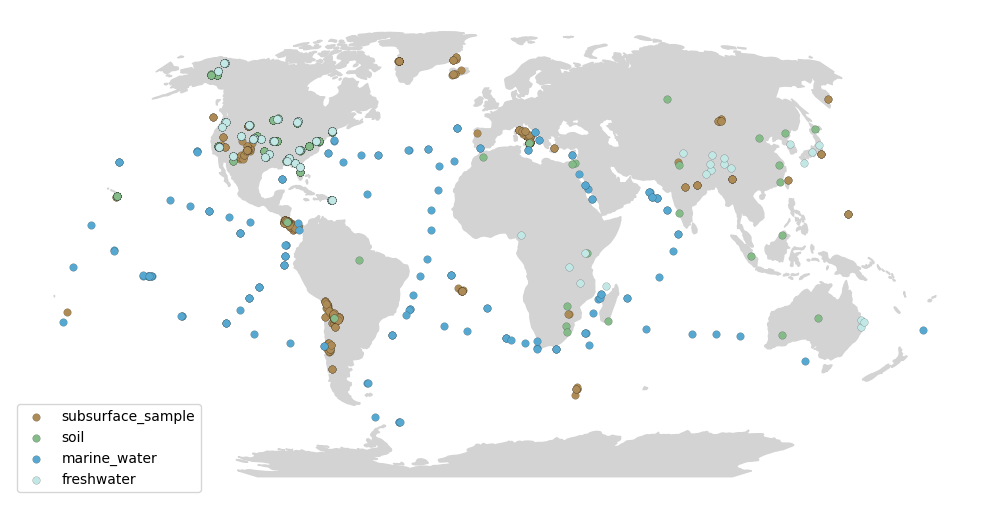

In [20]:
color_sample_group = {
    'subsurface_sample': "#ad8b56ff",
    'soil': "#85ba89ff",
    'marine_water': "#57a8d1ff",
    'freshwater': "#c2e8e5ff"
}

world = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
)

env_points = env.dropna(subset=["latitude", "longitude"]).copy()

env_points["geometry"] = env_points.apply(lambda row: Point(row["longitude"], row["latitude"]), axis=1)

gdf = gpd.GeoDataFrame(env_points, geometry="geometry", crs="EPSG:4326")

world_proj = world.to_crs("+proj=robin")
gdf_proj = gdf.to_crs(world_proj.crs)

fig, ax = plt.subplots(figsize=(10, 6))

world_proj.plot(ax=ax, color="lightgray", edgecolor="lightgray")

for group, color in color_sample_group.items():
    subset = gdf_proj[gdf_proj["sample_group"] == group]
    subset.plot(ax=ax, color=color, markersize=30, label=group, alpha=1, edgecolor="black", linewidth=0.1)

ax.set_axis_off()
plt.tight_layout()
ax.legend(loc="lower left")
plt.savefig("../outputs/world_map_samples_small_dots.svg", format="svg", dpi=300, transparent=True)

plt.show()

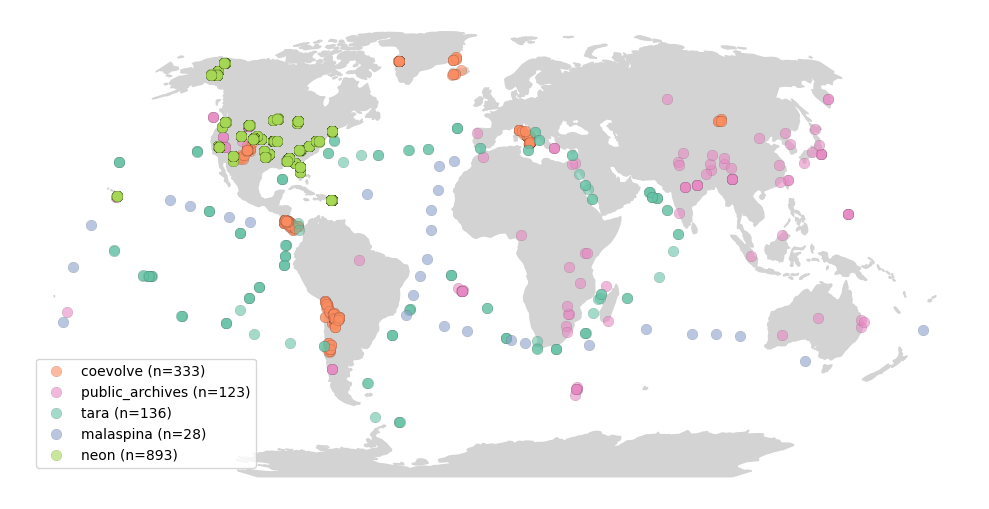

In [21]:
color_source = {
    'coevolve': "#fc8d62",
    'public_archives': "#e78ac3",
    'tara': "#66c2a5",
    'malaspina': "#8da0cb",
    'neon': "#a6d854",
}

world_proj = world.to_crs("+proj=robin")
gdf_proj = gdf.to_crs(world_proj.crs)

fig, ax = plt.subplots(figsize=(10, 6))

world_proj.plot(ax=ax, color="lightgray", edgecolor="lightgray")

for group, color in color_source.items():
    subset = gdf_proj[gdf_proj["source"] == group]

    # Skip empty groups to avoid useless legend entries
    if subset.empty:
        continue

    subset.plot(
        ax=ax,
        color=color,
        markersize=60,
        label=f"{group} (n={gdf_proj['source'].value_counts().get(group, 0)})",
        alpha=0.6,
        edgecolor="black",
        linewidth=0.1
    )

ax.set_axis_off()
plt.tight_layout()
ax.legend(loc="lower left", bbox_to_anchor=(0.02, 0.05))
plt.savefig("../outputs/world_map_samples_per_source.svg", format="svg", dpi=300, transparent=True)

In [22]:
print("Samples per sample_group:")
print(env["sample_group"].value_counts().sort_index())
print()
print("Samples per source:")
print(env["source"].value_counts().sort_index())
print()
print("Sample_group x Source summary table:")
print(pd.crosstab(env["sample_group"], env["source"]))

Samples per sample_group:
sample_group
freshwater           537
marine_water         164
soil                 400
subsurface_sample    412
Name: count, dtype: int64

Samples per source:
source
coevolve           333
malaspina           28
neon               893
public_archives    123
tara               136
Name: count, dtype: int64

Sample_group x Source summary table:
source             coevolve  malaspina  neon  public_archives  tara
sample_group                                                       
freshwater                0          0   517               20     0
marine_water              0         28     0                0   136
soil                      3          0   376               21     0
subsurface_sample       330          0     0               82     0
